<a href="https://colab.research.google.com/github/joaowinderfeldbussolotto/ml-salary-analysis/blob/main/Notebook_ML_Salarios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Projeto de Predição de Salários no Brasil**

### **Pós-Graduação | Documentação Técnica + Analítica + Deploy**

Este notebook foi estruturado para servir como **material de execução, documentação técnica e apoio à apresentação**.

Ele foi construído com base em:
- no projeto entregue em `ml-salary-analysis-main`;
- no padrão já iniciado no arquivo do Google Colab enviado;
- nos artefatos de deploy e documentação previamente gerados.

---

## **Objetivos deste notebook**

1. documentar o problema de negócio e a abordagem CRISP-DM;
2. apresentar o processo de carregamento, padronização e qualidade dos dados;
3. registrar as regras de consistência e as decisões técnicas adotadas;
4. consolidar a engenharia de atributos, modelagem e avaliação;
5. demonstrar como o modelo é consumido em predição e deploy;
6. oferecer um material profissional, reproduzível e explicativo.

## **Sumário Executivo**

Este projeto busca prever salários de profissionais no Brasil a partir de atributos como idade, experiência, escolaridade, idiomas, região e profissão.

A solução foi estruturada em um pipeline completo de Machine Learning com:
- tratamento de inconsistências de negócio;
- engenharia de atributos baseada em domínio;
- comparação entre múltiplos algoritmos;
- seleção do melhor modelo salvo em artefato reutilizável;
- disponibilização via API FastAPI e interface Gradio para deploy gratuito.

A proposta é tecnicamente consistente, reproduzível e adequada para apresentação acadêmica, porque mostra não apenas o resultado final, mas também **o raciocínio, os controles de qualidade e a preparação para uso real**.

# **1. Entendimento do Negócio (CRISP-DM)**

## **Contexto do problema**

Salário é uma variável influenciada por múltiplos fatores, como formação, experiência, ocupação, idioma e contexto regional. Em cenários de RH, consultoria, planejamento de carreira e análise de mercado, estimar remuneração de forma orientada por dados gera valor para decisões mais objetivas.

## **Problema de negócio**

Construir um modelo capaz de **estimar salário** com base em características observáveis do profissional e, ao mesmo tempo, explicar as principais decisões técnicas do pipeline.

## **Objetivo analítico**

Desenvolver uma solução ponta a ponta que:
- limpe e prepare dados salariais;
- reduza ruído causado por inconsistências;
- treine e compare diferentes modelos;
- selecione o melhor modelo;
- disponibilize a solução para consumo por API e interface web.

## **Critério de sucesso**

O sucesso do projeto não depende apenas de um erro baixo, mas de um conjunto de fatores:
- coerência metodológica;
- reprodutibilidade;
- justificativa das regras de negócio;
- capacidade de deploy gratuito;
- clareza para comunicação em ambiente acadêmico.

# **2. Desenho do Pipeline**

A figura a seguir resume o fluxo técnico do projeto, do dado bruto até o deploy:

![Pipeline do projeto](pipeline_ml_salarios.png)

## **Leitura do desenho**

O pipeline foi organizado em seis macroetapas:
1. ingestão do dataset bruto;
2. padronização e tratamento inicial;
3. aplicação de regras de consistência de negócio;
4. engenharia de atributos;
5. comparação de modelos e seleção do melhor artefato;
6. disponibilização por API e interface para deploy.

# **3. Importações e Configurações**

Nesta etapa, deixamos o notebook reproduzível e robusto para rodar tanto em ambiente local quanto no Google Colab.

In [ ]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import json
import os
import re
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

POSSIVEIS_RAIZES = [
    Path('.'),
    Path('/mnt/data/ml-salary-analysis-main'),
    Path('/content/ml-salary-analysis-main'),
    Path('/content'),
]

PROJECT_ROOT = None
for p in POSSIVEIS_RAIZES:
    if (p / 'data' / 'dataset_salarios_brasil.csv').exists() and (p / 'src').exists():
        PROJECT_ROOT = p
        break

if PROJECT_ROOT is None:
    raise FileNotFoundError('Não foi possível localizar a raiz do projeto automaticamente.')

DATA_PATH = PROJECT_ROOT / 'data' / 'dataset_salarios_brasil.csv'
RESULTS_PATH = PROJECT_ROOT / 'results' / 'model_comparison.csv'
BEST_META_PATH = PROJECT_ROOT / 'models' / 'best_model_meta.json'
BEST_MODEL_PATH = PROJECT_ROOT / 'models' / 'best_model.joblib'

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_PATH: {DATA_PATH}')
print(f'RESULTS_PATH existe? {RESULTS_PATH.exists()}')
print(f'BEST_MODEL_PATH existe? {BEST_MODEL_PATH.exists()}')

PROJECT_ROOT: /mnt/data/ml-salary-analysis-main
DATA_PATH: /mnt/data/ml-salary-analysis-main/data/dataset_salarios_brasil.csv
RESULTS_PATH existe? True
BEST_MODEL_PATH existe? True


# **4. Estrutura do Projeto**

Antes de analisar dados ou modelos, é importante registrar a arquitetura lógica do projeto, pois isso demonstra organização e preocupação com manutenção.

In [ ]:
from pathlib import Path

def exibir_arvore(path: Path, max_niveis: int = 2, prefixo: str = ''):
    if max_niveis < 0 or not path.exists():
        return []
    linhas = []
    itens = sorted(path.iterdir(), key=lambda x: (x.is_file(), x.name.lower()))
    for item in itens:
        linhas.append(f'{prefixo}- {item.name}/' if item.is_dir() else f'{prefixo}- {item.name}')
        if item.is_dir() and max_niveis > 0:
            linhas.extend(exibir_arvore(item, max_niveis - 1, prefixo + '  '))
    return linhas

print('\n'.join(exibir_arvore(PROJECT_ROOT, max_niveis=2)[:120]))

- .vscode/
  - settings.json
- data/
  - dataset_salarios_brasil.csv
- models/
  - best_model.joblib
  - best_model_meta.json
  - DecisionTree.joblib
  - Dummy_mediana.joblib
  - ElasticNet.joblib
  - GradientBoosting.joblib
  - KNN_k=10.joblib
  - Lasso.joblib
  - LightGBM.joblib
  - RandomForest.joblib
  - Ridge.joblib
  - XGBoost.joblib
- notebooks/
  - 02_resultados.py
- results/
  - model_comparison.csv
- src/
  - api/
    - __init__.py
    - app.py
  - pipeline/
    - __init__.py
    - features.py
    - models.py
    - preprocessing.py
    - train.py
  - __init__.py
- .gitignore
- app_hf.py
- dataset_salarios_brasil.csv
- Dockerfile
- imagemsalario.png
- Makefile
- mlflow_ui.py
- profissoes BR.txt
- README.md
- requirements.txt


# **5. Funções Auxiliares de Padronização**

Estas funções seguem o padrão iniciado no notebook do Google Colab e foram mantidas porque ajudam a construir um fluxo legível, reutilizável e explicável.

In [ ]:
def remover_acentos(texto):
    if not isinstance(texto, str):
        return texto
    return unicodedata.normalize('NFKD', texto).encode('ASCII', 'ignore').decode('utf-8')


def carregar_dataset(local_path=DATA_PATH):
    df_ = pd.read_csv(local_path)
    origem = f'Arquivo local: {local_path}'
    return df_, origem


def padronizar_colunas(df_):
    df_ = df_.copy()
    novas_colunas = []
    for col in df_.columns:
        col = str(col).strip()
        col = remover_acentos(col)
        col = col.replace('(R$)', '')
        col = col.replace(' ', '_')
        col = re.sub(r'[^A-Za-z0-9_]', '', col)
        col = re.sub(r'_+', '_', col)
        col = col.strip('_')
        novas_colunas.append(col)
    df_.columns = novas_colunas
    return df_


def padronizar_texto(df_):
    df_ = df_.copy()
    colunas_textuais = df_.select_dtypes(include='object').columns.tolist()
    for col in colunas_textuais:
        df_[col] = (
            df_[col]
            .astype(str)
            .str.strip()
            .replace({'': np.nan, 'nan': np.nan, 'None': np.nan, 'null': np.nan})
        )
    return df_


def converter_colunas_numericas(df_, colunas_numericas=('Idade','Anos_Experiencia','Salario')):
    df_ = df_.copy()
    for col in colunas_numericas:
        if col in df_.columns:
            df_[col] = pd.to_numeric(df_[col], errors='coerce')
    return df_


def preparar_base_inicial(df_):
    df_ = padronizar_colunas(df_)
    df_ = padronizar_texto(df_)
    df_ = converter_colunas_numericas(df_)
    return df_

# **6. Carregamento e Preparação Inicial**

Agora aplicamos o fluxo de carregamento e padronização, deixando a base pronta para o diagnóstico de qualidade.

In [ ]:
df_raw, origem_dados = carregar_dataset()
df = preparar_base_inicial(df_raw)

print('Origem dos dados:', origem_dados)
print('Shape original:', df_raw.shape)
print('Shape após padronização:', df.shape)
display(df.head())

Origem dos dados: Arquivo local: /mnt/data/ml-salary-analysis-main/data/dataset_salarios_brasil.csv
Shape original: (15000, 8)
Shape após padronização: (15000, 8)


,Idade,Anos_Experiencia,Escolaridade,Segunda_Lingua,Terceira_Lingua,Regiao,Profissao,Salario
0,56.00,22.00,Superior,Inglês,Italiano,Sudeste,Vendedor,NaN
1,46.00,11.00,Médio,Alemão,Francês,Sudeste,Consultor,NaN
2,32.00,26.00,Fundamental,Inglês,Nenhuma,Sul,Consultor,"6,606.26"
3,60.00,21.00,Pós,Francês,Nenhuma,Nordeste,Policial,"6,673.46"
4,25.00,31.00,Médio,Alemão,Espanhol,Centro-Oeste,Professor,"6,632.40"


# **7. Diagnóstico Inicial da Qualidade dos Dados**

Uma documentação profissional precisa mostrar claramente:
- quantidade de registros e colunas;
- tipos de dados;
- volume de valores ausentes;
- presença de valores inválidos;
- primeiros indícios de inconsistência.

In [ ]:
def relatorio_qualidade_inicial(df_raw, df_padronizado):
    resumo = pd.DataFrame({
        'coluna': df_padronizado.columns,
        'tipo': [str(df_padronizado[c].dtype) for c in df_padronizado.columns],
        'nulos': [df_padronizado[c].isna().sum() for c in df_padronizado.columns],
        'perc_nulos': [round(df_padronizado[c].isna().mean()*100, 2) for c in df_padronizado.columns],
        'n_unicos': [df_padronizado[c].nunique(dropna=True) for c in df_padronizado.columns],
    })
    return resumo.sort_values(['perc_nulos', 'coluna'], ascending=[False, True]).reset_index(drop=True)

qualidade_inicial = relatorio_qualidade_inicial(df_raw, df)
display(qualidade_inicial)

,coluna,tipo,nulos,perc_nulos,n_unicos
0,Anos_Experiencia,float64,498,3.32,40
1,Salario,float64,497,3.31,14444
2,Idade,float64,489,3.26,48
3,Escolaridade,object,0,0.00,7
4,Profissao,object,0,0.00,19
5,Regiao,object,0,0.00,5
6,Segunda_Lingua,object,0,0.00,5
7,Terceira_Lingua,object,0,0.00,6


In [ ]:
print('Valores ausentes por coluna:')
print(df.isna().sum())

print('\nEstatísticas descritivas numéricas:')
display(df[['Idade','Anos_Experiencia','Salario']].describe())

Valores ausentes por coluna:
Idade               489
Anos_Experiencia    498
Escolaridade          0
Segunda_Lingua        0
Terceira_Lingua       0
Regiao                0
Profissao             0
Salario             497
dtype: int64

Estatísticas descritivas numéricas:


,Idade,Anos_Experiencia,Salario
count,"14,511.00","14,502.00","14,503.00"
mean,41.48,19.48,"13,369.60"
std,13.80,11.51,"28,359.64"
min,18.00,0.00,"1,472.25"
25%,30.00,10.00,"6,064.06"
50%,41.00,19.00,"9,259.71"
75%,53.00,30.00,"14,077.34"
max,65.00,39.00,"768,761.00"


## **Leitura crítica do diagnóstico**

Os dados mostram um cenário típico de base realista para projeto acadêmico:
- há valores numéricos armazenados como texto;
- existem nulos em colunas essenciais;
- o target contém registros inválidos, como valores não numéricos;
- parte dos registros apresenta inconsistência lógica entre idade e experiência.

Esse diagnóstico justifica a necessidade de um pipeline de preparação mais criterioso antes da modelagem.

# **8. Regras de Consistência de Negócio**

As regras abaixo não são apenas técnicas: elas representam conhecimento de domínio aplicado ao problema.

## **Regras adotadas**

1. salário nulo ou inválido é removido, pois o alvo do modelo não pode ser imputado;
2. idade e anos de experiência recebem imputação pela mediana antes dos filtros dependentes dessas variáveis;
3. registros com `idade - anos_experiencia < 14` são considerados inconsistentes;
4. profissões que exigem nível superior não podem permanecer com escolaridade abaixo de `Superior`;
5. salários extremos acima do percentil 99,5 são removidos para reduzir distorção na função de custo.

In [ ]:
ORDEM_ESCOLARIDADE = ['Fundamental', 'Médio', 'Técnico', 'Superior', 'Pós', 'Mestrado', 'Doutorado']
NIVEL_ESC = {e: i for i, e in enumerate(ORDEM_ESCOLARIDADE)}
PROFISSOES_EXIGEM_SUPERIOR = {
    'Advogado', 'Agrônomo', 'Arquiteto', 'Cientista',
    'Economista', 'Engenheiro', 'Médico', 'Pesquisador'
}
OUTLIER_PERCENTIL = 0.995
DIF_IDADE_EXP_MINIMA = 14


def aplicar_regras_consistencia(df_):
    df_ = df_.copy()
    auditoria = []
    n_original = len(df_)

    n_antes = len(df_)
    df_ = df_.dropna(subset=['Salario'])
    auditoria.append(['Salário nulo ou inválido', n_antes - len(df_)])

    n_antes = len(df_)
    df_ = df_[df_['Salario'] > 0]
    auditoria.append(['Salário <= 0', n_antes - len(df_)])

    for col in ['Idade', 'Anos_Experiencia']:
        mediana = df_[col].median()
        nulos = int(df_[col].isna().sum())
        df_[col] = df_[col].fillna(mediana)
        auditoria.append([f'Imputação de nulos em {col} com mediana', nulos])

    df_['dif_idade_exp'] = df_['Idade'] - df_['Anos_Experiencia']
    n_antes = len(df_)
    df_ = df_[df_['dif_idade_exp'] >= DIF_IDADE_EXP_MINIMA]
    auditoria.append([f'dif_idade_exp < {DIF_IDADE_EXP_MINIMA}', n_antes - len(df_)])

    df_['_nivel_esc'] = df_['Escolaridade'].map(NIVEL_ESC)
    mask_inc = (
        df_['Profissao'].isin(PROFISSOES_EXIGEM_SUPERIOR) &
        (df_['_nivel_esc'] < NIVEL_ESC['Superior'])
    )
    removidos_escolaridade = int(mask_inc.sum())
    df_ = df_[~mask_inc].copy()
    auditoria.append(['Profissão exige superior + escolaridade insuficiente', removidos_escolaridade])
    df_.drop(columns=['_nivel_esc'], inplace=True)

    corte = df_['Salario'].quantile(OUTLIER_PERCENTIL)
    n_antes = len(df_)
    df_ = df_[df_['Salario'] <= corte].copy()
    auditoria.append([f'Outliers > p{OUTLIER_PERCENTIL*100:.1f}', n_antes - len(df_)])

    df_.reset_index(drop=True, inplace=True)

    auditoria_df = pd.DataFrame(auditoria, columns=['etapa', 'quantidade'])
    auditoria_df.loc[len(auditoria_df)] = ['Total removido (excluindo imputações)', n_original - len(df_)]
    auditoria_df.loc[len(auditoria_df)] = ['Total final de registros', len(df_)]
    return df_, auditoria_df, corte


df_limpo, auditoria_limpeza, corte_outlier = aplicar_regras_consistencia(df)
display(auditoria_limpeza)
print(f'Corte de outlier utilizado: R$ {corte_outlier:,.2f}')
print(f'Retenção da base: {len(df_limpo):,} de {len(df):,} registros ({len(df_limpo)/len(df)*100:.1f}%)')

,etapa,quantidade
0,Salário nulo ou inválido,497
1,Salário <= 0,0
2,Imputação de nulos em Idade com mediana,472
3,Imputação de nulos em Anos_Experiencia com med...,481
4,dif_idade_exp < 14,4746
5,Profissão exige superior + escolaridade insufi...,1664
6,Outliers > p99.5,41
7,Total removido (excluindo imputações),6948
8,Total final de registros,8052


Corte de outlier utilizado: R$ 227,633.55
Retenção da base: 8,052 de 15,000 registros (53.7%)


## **Interpretação da limpeza**

A limpeza não foi feita de forma arbitrária. Ela foi desenhada para preservar o máximo possível da base útil, sem permitir que registros logicamente inconsistentes contaminassem o treinamento.

Esse é um ponto importante para a banca: **o objetivo não foi “deixar o dataset bonito”, mas aumentar a confiabilidade analítica do processo**.

# **9. Engenharia de Atributos**

Após a limpeza, criamos variáveis derivadas com base em interpretação de domínio e na utilidade para modelagem.

In [ ]:
def engenharia_features(df_):
    df_ = df_.copy()
    df_['tem_segunda_lingua'] = (df_['Segunda_Lingua'] != 'Nenhuma').astype(int)
    df_['tem_terceira_lingua'] = (df_['Terceira_Lingua'] != 'Nenhuma').astype(int)
    df_['total_linguas'] = df_['tem_segunda_lingua'] + df_['tem_terceira_lingua']
    if 'dif_idade_exp' not in df_.columns:
        df_['dif_idade_exp'] = df_['Idade'] - df_['Anos_Experiencia']
    return df_


df_feat = engenharia_features(df_limpo)
display(df_feat.head())
print('Shape após feature engineering:', df_feat.shape)

,Idade,Anos_Experiencia,Escolaridade,Segunda_Lingua,Terceira_Lingua,Regiao,Profissao,Salario,dif_idade_exp,tem_segunda_lingua,tem_terceira_lingua,total_linguas
0,60.00,21.00,Pós,Francês,Nenhuma,Nordeste,Policial,"6,673.46",39.00,1,0,1
1,40.00,25.00,Superior,Inglês,Nenhuma,Centro-Oeste,Motorista,"3,865.02",15.00,1,0,1
2,41.00,4.00,Superior,Alemão,Nenhuma,Nordeste,Designer,"5,102.42",37.00,1,0,1
3,53.00,32.00,Mestrado,Alemão,Inglês,Sudeste,Advogado,"33,507.40",21.00,1,1,2
4,41.00,19.00,Doutorado,Italiano,Nenhuma,Sudeste,Designer,"16,251.64",22.00,1,0,1


Shape após feature engineering: (8052, 12)


## **Justificativa das features derivadas**

- `tem_segunda_lingua`: captura rapidamente se há diferenciação competitiva adicional;
- `tem_terceira_lingua`: reforça perfil multilíngue;
- `total_linguas`: consolida o efeito da pluralidade de idiomas;
- `dif_idade_exp`: funciona como variável de coerência e de maturidade profissional.

# **10. Análise Exploratória Orientada ao Problema**

Nesta seção, o foco não é fazer uma EDA exaustiva, mas sim registrar visualmente os principais comportamentos relevantes para o problema de regressão salarial.

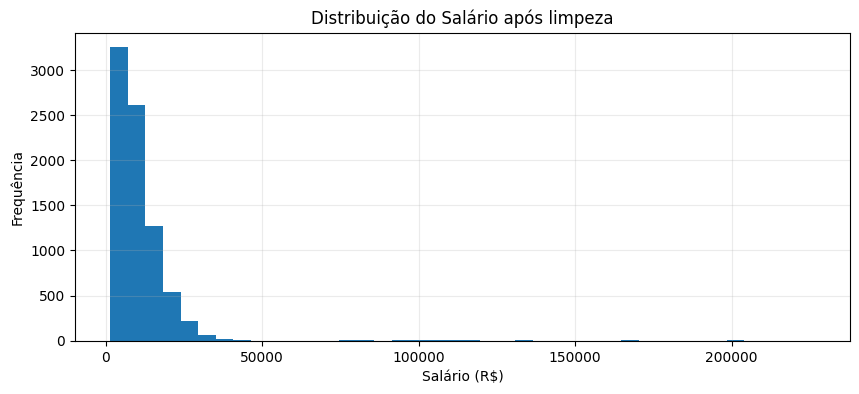

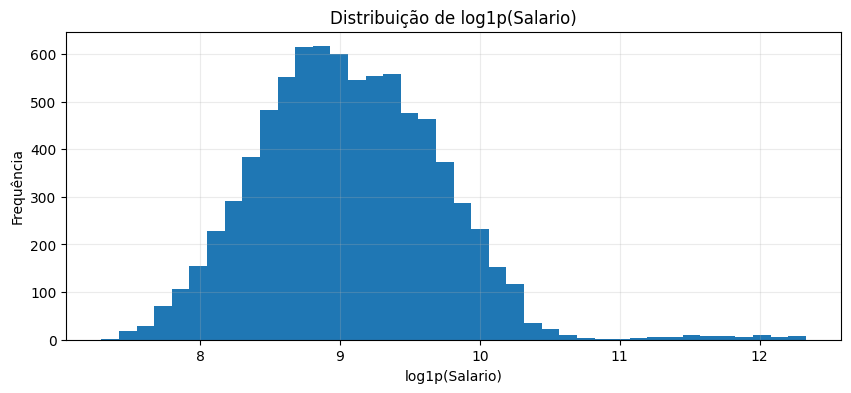

In [ ]:
fig, ax = plt.subplots(figsize=(10,4))
df_feat['Salario'].hist(ax=ax, bins=40)
ax.set_title('Distribuição do Salário após limpeza')
ax.set_xlabel('Salário (R$)')
ax.set_ylabel('Frequência')
plt.show()

fig, ax = plt.subplots(figsize=(10,4))
np.log1p(df_feat['Salario']).hist(ax=ax, bins=40)
ax.set_title('Distribuição de log1p(Salario)')
ax.set_xlabel('log1p(Salario)')
ax.set_ylabel('Frequência')
plt.show()

In [ ]:
resumo_profissao = (
    df_feat.groupby('Profissao')['Salario']
    .agg(['count','median','mean'])
    .sort_values('median', ascending=False)
)
display(resumo_profissao.head(10))

,count,median,mean
Profissao,,,
Engenheiro,324,"18,440.26","19,422.92"
Médico,304,"18,112.43","19,263.69"
Advogado,322,"18,004.51","19,891.74"
Pesquisador,316,"15,716.71","16,795.91"
Cientista,300,"15,373.59","16,478.59"
Arquiteto,320,"13,635.78","14,533.50"
Programador,510,"11,687.31","12,984.72"
Analista de Dados,491,"11,491.97","13,122.63"
Economista,295,"9,402.76","12,134.11"


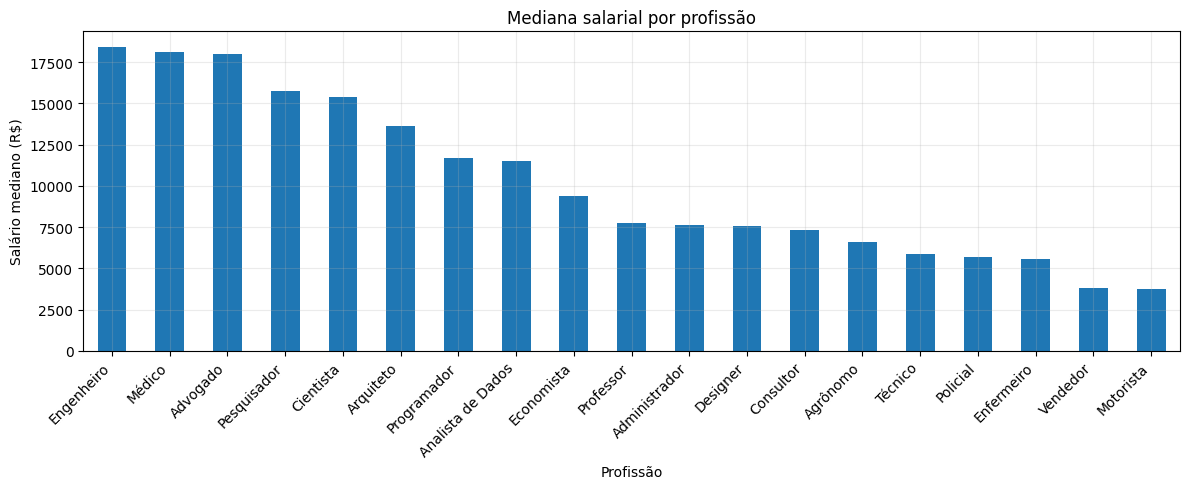

In [ ]:
fig, ax = plt.subplots(figsize=(12,5))
resumo_profissao['median'].sort_values(ascending=False).plot(kind='bar', ax=ax)
ax.set_title('Mediana salarial por profissão')
ax.set_xlabel('Profissão')
ax.set_ylabel('Salário mediano (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
resumo_escolaridade = (
    df_feat.groupby('Escolaridade')['Salario']
    .agg(['count','median','mean'])
    .reindex([e for e in ORDEM_ESCOLARIDADE if e in df_feat['Escolaridade'].unique()])
)
display(resumo_escolaridade)

,count,median,mean
Escolaridade,,,
Fundamental,246,"4,032.51","6,194.67"
Médio,1090,"5,255.42","6,600.19"
Técnico,882,"5,688.18","7,379.73"
Superior,2891,"8,609.84","10,679.86"
Pós,991,"10,662.42","12,664.78"
Mestrado,962,"11,667.74","14,700.04"
Doutorado,990,"15,033.45","17,150.51"


## **Leituras analíticas relevantes**

Os gráficos e tabelas reforçam alguns pontos importantes:
- a distribuição salarial é assimétrica, justificando o uso de `log1p(Salario)`;
- a profissão exerce forte influência no salário;
- escolaridade também apresenta comportamento compatível com crescimento salarial;
- mesmo assim, há variabilidade interna importante, indicando que o problema não é totalmente explicado por poucas variáveis.

# **11. Modelagem e Avaliação**

Em vez de depender apenas de um único algoritmo, o projeto compara diferentes famílias de modelos e registra seus resultados em arquivo de saída.

Essa estratégia é mais profissional porque evita escolha arbitrária de algoritmo e sustenta a seleção final com evidência empírica.

In [ ]:
resultados = pd.read_csv(RESULTS_PATH)
resultados_ordenados = resultados.sort_values('rmse').reset_index(drop=True)
display(resultados_ordenados[['nome','rmse','mae','r2','mape','tempo_treino_s']])

,nome,rmse,mae,r2,mape,tempo_treino_s
0,XGBoost,"10,100.26","1,978.74",0.24,14.15,1.32
1,LightGBM,"10,118.41","2,017.24",0.24,14.51,0.33
2,GradientBoosting,"10,172.62","2,014.70",0.23,14.41,2.84
3,RandomForest,"10,201.80","2,137.30",0.23,15.48,3.13
4,ElasticNet,"10,215.05","2,288.73",0.23,16.68,0.02
5,Lasso,"10,374.92","2,760.11",0.20,21.28,0.02
6,KNN (k=10),"10,665.05","3,445.20",0.16,31.02,0.01
7,Dummy (mediana),"11,908.06","5,409.10",-0.05,55.25,0.04
8,DecisionTree,"12,334.30","3,623.33",-0.13,33.49,0.03


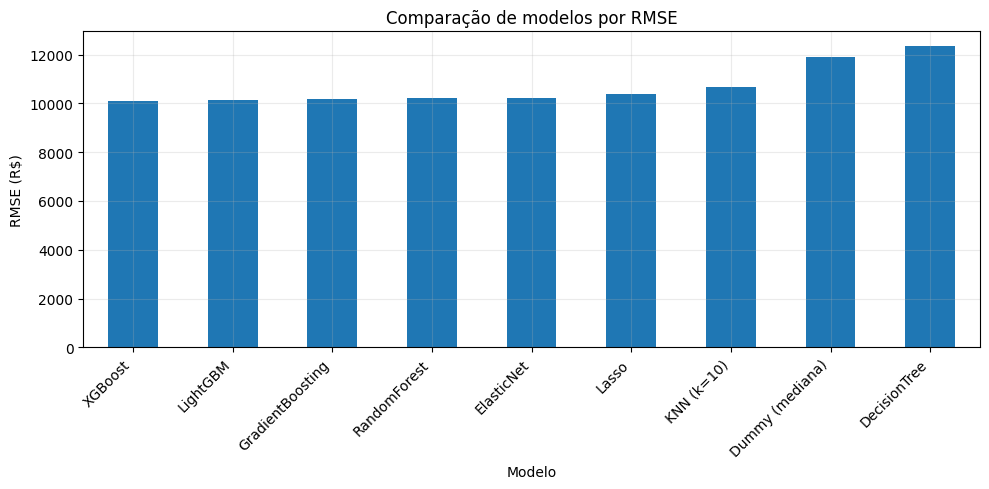

In [ ]:
fig, ax = plt.subplots(figsize=(10,5))
resultados_ordenados.plot(x='nome', y='rmse', kind='bar', ax=ax, legend=False)
ax.set_title('Comparação de modelos por RMSE')
ax.set_xlabel('Modelo')
ax.set_ylabel('RMSE (R$)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
with open(BEST_META_PATH, 'r', encoding='utf-8') as f:
    best_meta = json.load(f)

print('Melhor modelo salvo:')
print(json.dumps(best_meta, indent=2, ensure_ascii=False))

Melhor modelo salvo:
{
  "nome": "XGBoost",
  "rmse_teste": 10100.262331490949,
  "mae_teste": 1978.743068106596,
  "r2_teste": 0.24493076062194274,
  "mape_teste": 14.147629201235231
}


## **Conclusão da modelagem**

Pelos arquivos efetivamente presentes no projeto, o melhor modelo salvo foi o **XGBoost**.

Os resultados mostram um cenário realista para um problema salarial:
- **RMSE** em torno de R$ 10 mil;
- **MAE** próximo de R$ 2 mil;
- **R²** por volta de 0,24.

Esse nível de desempenho é coerente com problemas nos quais parte importante da variação depende de fatores não observados, como porte da empresa, setor, negociação individual, benefícios, senioridade específica e contexto econômico.

# **12. Exemplo de Predição com o Artefato Salvo**

Esta etapa demonstra como o modelo treinado pode ser reutilizado. Isso é relevante para a banca porque mostra a transição do experimento para a aplicação.

In [ ]:
import joblib
import sys

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

modelo = joblib.load(BEST_MODEL_PATH)

perfil_exemplo = pd.DataFrame({
    'Idade': [35],
    'Anos_Experiencia': [10],
    'Escolaridade': ['Superior'],
    'Regiao': ['Sudeste'],
    'Profissao': ['Engenheiro'],
    'Segunda_Lingua': ['Inglês'],
    'Terceira_Lingua': ['Nenhuma'],
    'tem_segunda_lingua': [1],
    'tem_terceira_lingua': [0],
    'total_linguas': [1],
    'dif_idade_exp': [25],
})

pred_log = modelo.predict(perfil_exemplo)[0]
pred_salario = float(np.expm1(pred_log))

print(f'Salário estimado: R$ {pred_salario:,.2f}')
print(f'Intervalo aproximado usando MAE: de R$ {max(0, pred_salario - best_meta["mae_teste"]):,.2f} até R$ {pred_salario + best_meta["mae_teste"]:,.2f}')

Salário estimado: R$ 17,543.07
Intervalo aproximado usando MAE: de R$ 15,564.33 até R$ 19,521.82


# **13. Código-Fonte de Referência do Treinamento**

Abaixo, registramos programaticamente o script principal de treinamento para fins de documentação. Isso ajuda a demonstrar rastreabilidade entre notebook e projeto produtivo.

In [ ]:
train_script = PROJECT_ROOT / 'src' / 'pipeline' / 'train.py'
with open(train_script, 'r', encoding='utf-8') as f:
    conteudo_train = f.read()

print(conteudo_train[:5000])
print('\n... [trecho truncado para visualização no notebook] ...')

"""
train.py
Script principal de treinamento. Rode sempre a partir da raiz do projeto:

    python src/pipeline/train.py

Fluxo CRISP-DM:
  1. Carrega e limpa os dados (todos os filtros de inconsistência)
  2. Feature engineering
  3. Split 80/20 estratificado por Profissão
  4. Para cada modelo: treina, avalia com CV-5 e holdout, loga no MLflow
  5. Salva o melhor modelo em models/best_model.joblib

Métricas (calculadas na escala original R$, revertendo o log1p):
  RMSE, MAE, R², MAPE
"""

import json
import sys
import time
import warnings
from pathlib import Path

import joblib
import mlflow
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path(__file__).resolve().parents[2]
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from pipeline.features import bui

# **14. Arquitetura de Deploy Gratuito**

O projeto foi preparado para deploy gratuito com duas frentes principais:

## **Opção recomendada: Hugging Face Spaces**

Pontos fortes:
- gratuito para demonstrações e projetos acadêmicos;
- ótimo para apps com interface Gradio;
- build automatizado após upload do repositório.

## **Opção complementar: Docker + API FastAPI**

Pontos fortes:
- excelente para demonstrar arquitetura moderna;
- facilita transição para Render, Railway ou servidores próprios;
- aproxima o projeto de um padrão profissional de produção.

## **Fluxo de deploy**

1. modelo treinado salvo em `models/best_model.joblib`;
2. API carrega o artefato e expõe endpoint `/predizer`;
3. interface Gradio consome o mesmo artefato para uso web;
4. Docker empacota a solução completa;
5. Hugging Face Spaces viabiliza apresentação pública gratuita.

In [ ]:
readme_deploy = PROJECT_ROOT / 'README.md'
with open(readme_deploy, 'r', encoding='utf-8') as f:
    linhas = f.readlines()

inicio = ''.join(linhas[:220])
print(inicio)

# Predição de Salários — Brasil

> **UC Aprendizado de Máquina 2026/1 — Projeto Final**
>
>  **Este conteúdo é destinado apenas para fins educacionais. Os dados exibidos são ilustrativos e podem não corresponder a situações reais.**

---

## Estrutura do Projeto

```
salarios-ml/
├── data/
│   └── dataset_salarios_brasil.csv
├── models/                         # criado ao treinar
│   ├── best_model.joblib
│   ├── best_model_meta.json
│   └── *.joblib                    # um por modelo
├── results/                        # criado ao treinar
│   └── model_comparison.csv
├── mlruns/                         # criado pelo MLflow ao treinar
├── notebooks/
│   └── 02_resultados.py
├── src/
│   ├── pipeline/
│   │   ├── preprocessing.py        # limpeza + feature engineering
│   │   ├── features.py             # ColumnTransformer sklearn
│   │   ├── models.py               # catálogo de modelos
│   │   └── train.py                # script principal
│   └── api/
│       └── app.py              

# **15. Boas Práticas Evidenciadas no Projeto**

Este projeto demonstra diversas práticas esperadas em uma documentação:

- separação entre notebook exploratório e código produtivo;
- modularização em `preprocessing.py`, `features.py`, `models.py` e `train.py`;
- persistência de artefatos em pasta `models/`;
- comparação de resultados em `results/model_comparison.csv`;
- preparação para rastreabilidade de experimentos com MLflow;
- disponibilização do modelo via API;
- estratégia de deploy gratuita para fins acadêmicos.

# **16. Conclusão Final**

O projeto vai além de uma simples predição salarial. Ele apresenta uma solução de Machine Learning documentada de ponta a ponta, com:
- entendimento do problema;
- tratamento criterioso dos dados;
- regras de negócio justificadas;
- engenharia de atributos;
- avaliação comparativa de modelos;
- reaproveitamento do melhor artefato;
- possibilidade real de deploy gratuito.